# 导入库和加载数据

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 数据准备
df = pd.read_csv('Concrete_Data_Yeh.csv')
X = df.drop(columns=['csMPa']).values
y = df['csMPa'].values

分割数据集：将数据集的前 80% 作为训练集，后 20% 作为测试集

In [3]:
train_size = int(0.8 * len(df))
X_train_raw, X_test_raw = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

数据预处理

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# PCA主成分分析

In [5]:
# 提取能够解释大部分数据方差（95%）的主成分
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_components = X_train_pca.shape[1]
print(f"原始特征维度: 8, PCA降维后维度: {n_components}")

原始特征维度: 8, PCA降维后维度: 6


# 构建线性回归模型

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train_pca, y_train)

# 模型测试和评估
y_pred = lr_model.predict(X_test_pca)
mse = mean_squared_error(y_test, y_pred)
print(f"测试集均方误差 (Test MSE): {mse:.4f}")

测试集均方误差 (Test MSE): 128.0168


# 可视化分析

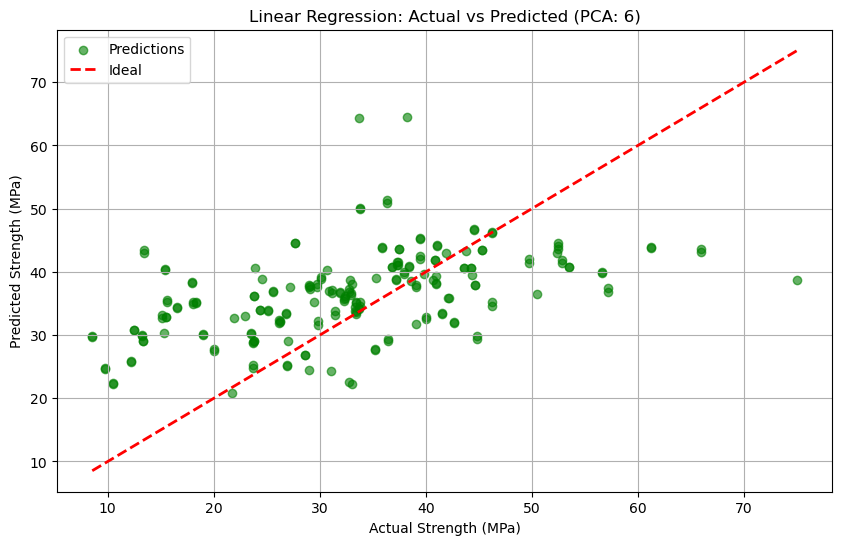

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title(f'Linear Regression: Actual vs Predicted (PCA: {n_components})')
plt.legend()
plt.grid(True)
plt.show()

 在原始数据集中，有8个输入特征，进行PCA降维后剩余6个主成分特征。
 经过线性回归建模后，测试的均方误差MSE为128.0168。
 采用同样的PCA分析，改用神经网络建模。

# 神经网络建模

Epoch [50/500], Loss: 159.8340
Epoch [100/500], Loss: 133.5413
Epoch [150/500], Loss: 122.0062
Epoch [200/500], Loss: 115.0120
Epoch [250/500], Loss: 100.2584
Epoch [300/500], Loss: 55.3569
Epoch [350/500], Loss: 41.6820
Epoch [400/500], Loss: 33.7918
Epoch [450/500], Loss: 28.9503
Epoch [500/500], Loss: 26.1636
测试集均方误差 (Test MSE): 451.4089


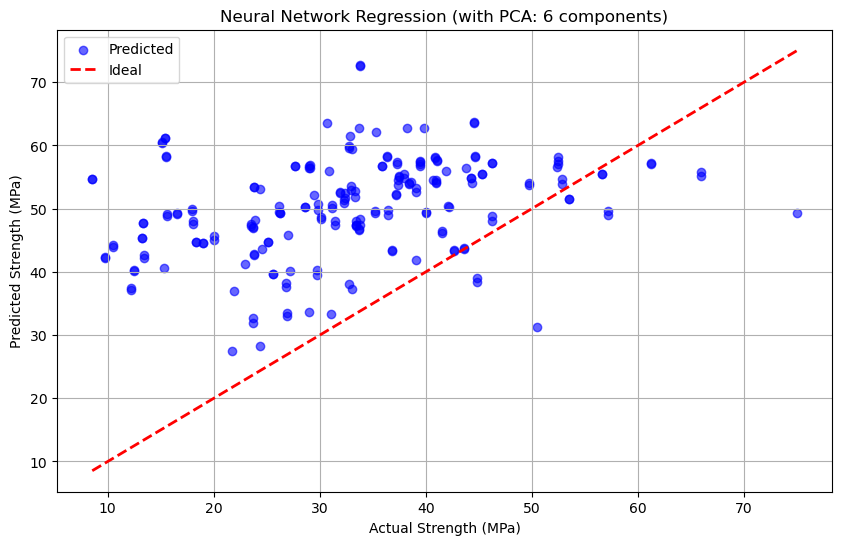

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# 转换为 PyTorch 张量
X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# 3. 神经网络构建
class ConcreteRegressionNet(nn.Module):
    def __init__(self, input_dim):
        super(ConcreteRegressionNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)


model = ConcreteRegressionNet(n_components)
criterion = nn.MSELoss()  # 均方误差
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 模型训练
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

# 5. 模型测试和评估
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_mse = criterion(predictions, y_test_tensor)
    print(f'测试集均方误差 (Test MSE): {test_mse.item():.4f}')

# 绘图可视化：测试集的 target 与神经网络模型输出的 output
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions.numpy(), alpha=0.6, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title(f'Neural Network Regression (with PCA: {n_components} components)')
plt.legend()
plt.grid(True)
plt.show()

 经过神经网络建模后，测试的均方误差MSE为451.4089，大于线性回归的MSE。散点图展示了预测值与实际值的偏离程度，相比之下，线性回归在本数据集上的表现通常更为稳定，但其拟合上限受限于线性关系的假设。线性回归模型更加简单、计算速度快，且拥有较好的可解释性。